# Modeling

## Part 0: Importing Libraries

In [5]:
import os
import random
import zipfile
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from tqdm.auto import tqdm
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm

import random
import io

In [6]:
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

2.5.1+cu121
True
NVIDIA GeForce RTX 3060


## Part 1: Data Preprocessing

In [7]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

In [8]:
data_root ="../../dataset"
print(os.listdir(data_root))

['test', 'train', 'val']


In [9]:
class RandomJPEGCompression:
    def __init__(self, quality_range=(25, 70), p=0.5):
        self.quality_range = quality_range
        self.p = p

    def __call__(self, img):
        if random.random() > self.p:
            return img

        buffer = io.BytesIO()
        quality = random.randint(*self.quality_range)
        img.save(buffer, format="JPEG", quality=quality)
        buffer.seek(0)
        return Image.open(buffer).convert("RGB")

In [10]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),
    RandomJPEGCompression(quality_range=(25, 70), p=0.5),  # compression robustness
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [11]:
class VideoFrameDataset(Dataset):
    """
    One sample = one video folder containing multiple frame images.
    Returns:
        frames_tensor: shape (T, C, H, W)
        label: 0 for fake, 1 for real
    """

    IMG_EXTS = (".jpg", ".jpeg", ".png")

    def __init__(self, root_dir, transform=None, num_frames=8, mode="uniform"):
        self.root_dir = root_dir
        self.transform = transform
        self.num_frames = num_frames
        self.mode = mode  # "uniform" or "random"

        self.classes = ["fake", "real"]
        self.class_to_idx = {"fake": 0, "real": 1}
        self.samples = []

        for class_name in self.classes:
            class_dir = os.path.join(root_dir, class_name)
            if not os.path.isdir(class_dir):
                continue

            for video_name in sorted(os.listdir(class_dir)):
                video_dir = os.path.join(class_dir, video_name)
                if not os.path.isdir(video_dir):
                    continue

                frame_files = sorted([
                    os.path.join(video_dir, f)
                    for f in os.listdir(video_dir)
                    if f.lower().endswith(self.IMG_EXTS)
                ])

                if len(frame_files) == 0:
                    continue

                self.samples.append((frame_files, self.class_to_idx[class_name], video_dir))

        print(f"[{root_dir}] Found {len(self.samples)} videos.")

    def __len__(self):
        return len(self.samples)

    def _sample_indices(self, n_frames):
        if n_frames >= self.num_frames:
            if self.mode == "random":
                indices = sorted(random.sample(range(n_frames), self.num_frames))
            else:
                indices = np.linspace(0, n_frames - 1, self.num_frames, dtype=int).tolist()
        else:
            # Repeat frames if video has fewer than num_frames
            indices = np.linspace(0, n_frames - 1, self.num_frames, dtype=int).tolist()

        return indices

    def __getitem__(self, idx):
        frame_files, label, video_dir = self.samples[idx]
        indices = self._sample_indices(len(frame_files))

        frames = []
        for i in indices:
            img_path = frame_files[i]
            img = Image.open(img_path).convert("RGB")

            if self.transform is not None:
                img = self.transform(img)

            frames.append(img)

        frames = torch.stack(frames, dim=0)  # (T, C, H, W)
        return frames, torch.tensor(label, dtype=torch.float32)

In [12]:
NUM_FRAMES = 16
BATCH_SIZE = 8  # lower than frame model because sequence model uses more memory

train_dataset = VideoFrameDataset(
    root_dir=os.path.join(data_root, "train"),
    transform=train_transform,
    num_frames=NUM_FRAMES,
    mode="random" # uniform
)

val_dataset = VideoFrameDataset(
    root_dir=os.path.join(data_root, "val"),
    transform=val_test_transform,
    num_frames=NUM_FRAMES,
    mode="uniform"
)

test_dataset = VideoFrameDataset(
    root_dir=os.path.join(data_root, "test"),
    transform=val_test_transform,
    num_frames=NUM_FRAMES,
    mode="uniform"
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

[../../dataset\train] Found 508 videos.
[../../dataset\val] Found 108 videos.
[../../dataset\test] Found 111 videos.


In [13]:
videos, labels = next(iter(train_loader))
print("Video batch shape:", videos.shape)   # (B, T, C, H, W)
print("Labels shape:", labels.shape)

Video batch shape: torch.Size([8, 16, 3, 224, 224])
Labels shape: torch.Size([8])


## Part 2: Build and Fit the Model

In [14]:
import torch
import torch.nn as nn
import timm


class CNN_ViT_BiLSTM(nn.Module):

    def __init__(
        self,
        cnn_model='efficientnet_b0',
        vit_model='deit_tiny_patch16_224',
        proj_dim=128,
        lstm_hidden=128,
        lstm_layers=1,
        dropout=0.4194,
        freeze_cnn=True,
        freeze_vit=True
    ):
        super().__init__()

        # =====================================================
        # CNN Backbone
        # =====================================================

        self.cnn = timm.create_model(
            cnn_model,
            pretrained=True
        )

        self.cnn.reset_classifier(0)

        # =====================================================
        # ViT Backbone
        # =====================================================

        self.vit = timm.create_model(
            vit_model,
            pretrained=True
        )

        self.vit.reset_classifier(0)

        # =====================================================
        # Automatic Feature Dimension Inference
        # =====================================================

        with torch.no_grad():

            dummy = torch.randn(1, 3, 224, 224)

            cnn_out = self.cnn(dummy)
            cnn_feature_dim = cnn_out.shape[1]

            vit_out = self.vit(dummy)
            vit_feature_dim = vit_out.shape[1]

        # =====================================================
        # Freeze Backbones
        # =====================================================

        if freeze_cnn:
            for param in self.cnn.parameters():
                param.requires_grad = False

        if freeze_vit:
            for param in self.vit.parameters():
                param.requires_grad = False

        # =====================================================
        # Projection Layers
        # =====================================================

        self.cnn_proj = nn.Sequential(
            nn.Linear(cnn_feature_dim, proj_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        self.vit_proj = nn.Sequential(
            nn.Linear(vit_feature_dim, proj_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # =====================================================
        # Fusion
        # =====================================================

        self.fusion_norm = nn.LayerNorm(proj_dim * 2)

        # =====================================================
        # Temporal Modeling
        # =====================================================

        self.lstm = nn.LSTM(
            input_size=proj_dim * 2,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=True,
            dropout=0.0 if lstm_layers == 1 else dropout
        )

        # =====================================================
        # Classification Head
        # =====================================================

        self.classifier = nn.Sequential(
            nn.Linear(lstm_hidden * 2, 128),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(128, 1)
        )

    def forward(self, x):

        # =====================================================
        # Input Shape
        # x -> (B, T, C, H, W)
        # =====================================================

        B, T, C, H, W = x.shape

        x = x.view(B * T, C, H, W)

        # =====================================================
        # CNN Features
        # =====================================================

        cnn_feat = self.cnn(x)

        # =====================================================
        # ViT Features
        # =====================================================

        vit_feat = self.vit(x)

        # =====================================================
        # Projection
        # =====================================================

        cnn_feat = self.cnn_proj(cnn_feat)

        vit_feat = self.vit_proj(vit_feat)

        # =====================================================
        # Fusion
        # =====================================================

        fused = torch.cat(
            [cnn_feat, vit_feat],
            dim=1
        )

        fused = self.fusion_norm(fused)

        # =====================================================
        # Sequence Reshape
        # =====================================================

        seq_feat = fused.view(B, T, -1)

        # =====================================================
        # BiLSTM
        # =====================================================

        lstm_out, _ = self.lstm(seq_feat)

        # =====================================================
        # Temporal Pooling
        # =====================================================

        temporal_feat = lstm_out.mean(dim=1)

        # =====================================================
        # Classification
        # =====================================================

        out = self.classifier(temporal_feat)

        return out

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN_ViT_BiLSTM().to(device)

In [16]:

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.AdamW([

    # Classification head
    {
        "params": model.classifier.parameters(),
        "lr": 3e-4
    },

    # Temporal module
    {
        "params": model.lstm.parameters(),
        "lr": 3e-4
    },

    # Projection layers
    {
        "params": model.cnn_proj.parameters(),
        "lr": 3e-4
    },

    {
        "params": model.vit_proj.parameters(),
        "lr": 3e-4
    },

    # Pretrained CNN backbone
    {
        "params": model.cnn.parameters(),
        "lr": 3e-5
    },

    # Pretrained ViT backbone
    {
        "params": model.vit.parameters(),
        "lr": 3e-5
    },

], weight_decay=1e-5)


In [17]:
# =========================================================
# Scheduler
# =========================================================
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=3,
    verbose=True
)

c:\Users\fatah.rahimi\Desktop\Models\my_env\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [18]:

print(device)

cuda


In [19]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    all_labels = []
    all_preds = []

    for videos, labels in tqdm(loader, desc="Training"):
        videos = videos.to(device)
        labels = labels.unsqueeze(1).to(device)

        optimizer.zero_grad()
        outputs = model(videos)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()

        all_labels.extend(labels.cpu().numpy().ravel())
        all_preds.extend(preds.cpu().numpy().ravel())

    epoch_loss = running_loss / len(loader)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds)

    return epoch_loss, epoch_acc, epoch_f1


def validate_one_epoch(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for videos, labels in tqdm(loader, desc="Validation"):
            videos = videos.to(device)
            labels = labels.unsqueeze(1).to(device)

            outputs = model(videos)
            loss = criterion(outputs, labels)

            running_loss += loss.item()

            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).float()

            all_labels.extend(labels.cpu().numpy().ravel())
            all_preds.extend(preds.cpu().numpy().ravel())
            all_probs.extend(probs.cpu().numpy().ravel())

    epoch_loss = running_loss / len(loader)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds)
    epoch_auc = roc_auc_score(all_labels, all_probs)

    return epoch_loss, epoch_acc, epoch_f1, epoch_auc

In [20]:
import wandb

In [21]:
wandb.login(key= "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")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\fatah.rahimi\_netrc
wandb: Currently logged in as: fatah-rahimi (fatah-rahimi-nu) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [22]:
wandb.init(project = "model_9.1",id="silvery-grass-9.1",resume="allow")

In [23]:
wandb.watch(model)

In [24]:
checkpoint_path = "video_checkpoint.pth"
model_path = "video_model.pth"

epochs = 50
patience = 10
counter = 0
best_val_f1 = 0.0
start_epoch = 0

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []
train_f1s, val_f1s = [], []
val_aucs = []


# =========================================================
# Load checkpoint safely
# =========================================================
if os.path.exists(checkpoint_path):

    print("Loading checkpoint...")

    checkpoint = torch.load(checkpoint_path, map_location=device)

    # Load model weights
    model.load_state_dict(checkpoint["model_state_dict"])

    # Load optimizer safely
    try:
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
        print("Optimizer restored successfully")

    except ValueError:
        print("Optimizer structure changed -> using fresh optimizer")

    # Restore training state
    start_epoch = checkpoint["epoch"] + 1
    best_val_f1 = checkpoint.get("best_val_f1", 0.0)
    counter = checkpoint.get("counter", 0)

    train_losses = checkpoint.get("train_losses", [])
    val_losses = checkpoint.get("val_losses", [])

    train_accuracies = checkpoint.get("train_accuracies", [])
    val_accuracies = checkpoint.get("val_accuracies", [])

    train_f1s = checkpoint.get("train_f1s", [])
    val_f1s = checkpoint.get("val_f1s", [])

    val_aucs = checkpoint.get("val_aucs", [])

    print(f"Resuming from epoch {start_epoch}")

# =========================================================
# Training Loop
# =========================================================
for epoch in range(start_epoch, epochs):

    print(f"\nEpoch {epoch+1}/{epochs}")

    # =====================================================
    # Unfreeze at epoch 8
    # =====================================================
    if epoch == 5:

        print("🔓 Unfreezing CNN + ViT")

        for param in model.cnn.parameters():
            param.requires_grad = True

        for param in model.vit.parameters():
            param.requires_grad = True

        

    # =====================================================
    # Train
    # =====================================================
    train_loss, train_acc, train_f1 = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    # =====================================================
    # Validation
    # =====================================================
    val_loss, val_acc, val_f1, val_auc = validate_one_epoch(
        model,
        val_loader,
        criterion,
        device
    )

    # =====================================================
    # Scheduler Step
    # =====================================================
    scheduler.step(val_f1)

    # =====================================================
    # Save Metrics
    # =====================================================
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    train_f1s.append(train_f1)
    val_f1s.append(val_f1)

    val_aucs.append(val_auc)

    # =====================================================
    # Print Results
    # =====================================================
    print(
        f"Train Loss={train_loss:.4f}, "
        f"Train Acc={train_acc:.4f}, "
        f"Train F1={train_f1:.4f} | "
        f"Val Loss={val_loss:.4f}, "
        f"Val Acc={val_acc:.4f}, "
        f"Val F1={val_f1:.4f}, "
        f"Val AUC={val_auc:.4f}"
    )

    torch.save(model.state_dict(), model_path)
    # =====================================================
    # Save Checkpoint
    # =====================================================
    torch.save({

        "epoch": epoch,

        "model_state_dict": model.state_dict(),

        "optimizer_state_dict": optimizer.state_dict(),

        "best_val_f1": best_val_f1,

        "counter": counter,

        "train_losses": train_losses,
        "val_losses": val_losses,

        "train_accuracies": train_accuracies,
        "val_accuracies": val_accuracies,

        "train_f1s": train_f1s,
        "val_f1s": val_f1s,

        "val_aucs": val_aucs

    }, checkpoint_path)

    # =====================================================
    # WandB Logging
    # =====================================================
    wandb.log({

    "Accuracy/Train": train_acc,
    "Accuracy/Validation": val_acc,

    "Loss/Train": train_loss,
    "Loss/Validation": val_loss,

    "F1/Train": train_f1,
    "F1/Validation": val_f1,

    "AUC/Validation": val_auc

}, step=epoch)
    # =====================================================
    # Early Stopping
    # =====================================================
    if counter >= patience:

        print("⛔ Early stopping triggered")
        break

# =========================================================
# Finish WandB
# =========================================================
wandb.finish()


Epoch 1/50


Validation: 100%|██████████| 14/14 [00:05<00:00,  2.57it/s]


Train Loss=0.6315, Train Acc=0.6909, Train F1=0.7021 | Val Loss=0.6177, Val Acc=0.6667, Val F1=0.5000, Val AUC=0.9307

Epoch 2/50


Validation: 100%|██████████| 14/14 [00:04<00:00,  3.11it/s]


Train Loss=0.3278, Train Acc=0.8720, Train F1=0.8682 | Val Loss=0.5802, Val Acc=0.7870, Val F1=0.7294, Val AUC=0.9794

Epoch 3/50


...

Train Loss=0.0224, Train Acc=0.9902, Train F1=0.9901 | Val Loss=0.0728, Val Acc=0.9630, Val F1=0.9623, Val AUC=0.9986

Epoch 50/50


Validation: 100%|██████████| 14/14 [00:19<00:00,  1.41s/it]


Train Loss=0.0279, Train Acc=0.9882, Train F1=0.9882 | Val Loss=0.0792, Val Acc=0.9630, Val F1=0.9623, Val AUC=0.9990


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


AUC/Validation,▁▆▆▆▆▆▇▇▇▇██████████████████████████████
Accuracy/Train,▁▅▇▇▇▇▇▇▇▇▇▇████████████████████████████
Accuracy/Validation,▁▄▆▇█▇▇█▇███████████████████████████████
F1/Train,▁▅▆▇▇▇▇▇▇▇▇▇████▇███████████████████████
F1/Validation,▁▄▆▇█▇▇█████████████████████████████████
Loss/Train,█▅▅▅▅▄▄▃▃▃▃▂▂▂▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▂▁▁▁▁
Loss/Validation,█▅▄▃▄▃▂▃▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▂▁▂▂▂▁▁▁▁▁▁▁▂▁▁▁▁
AUC/Validation,0.99897
Accuracy/Train,0.98819
Accuracy/Validation,0.96296
F1/Train,0.98819


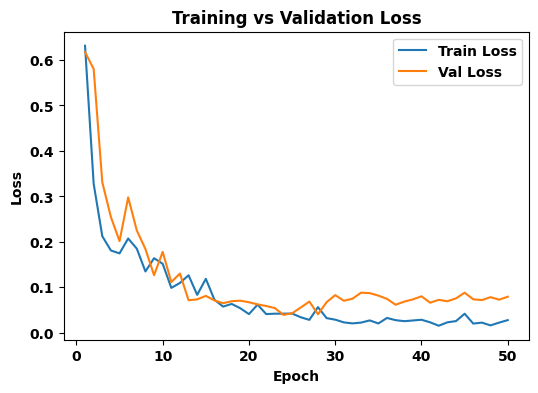

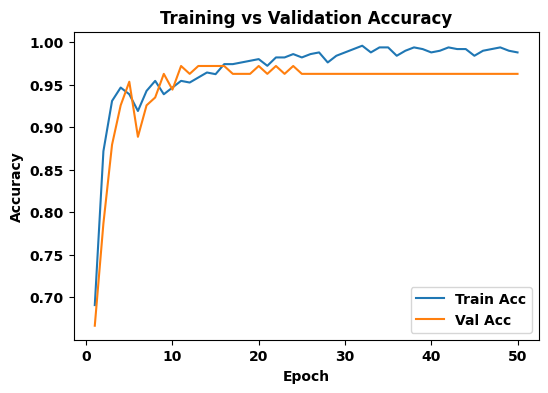

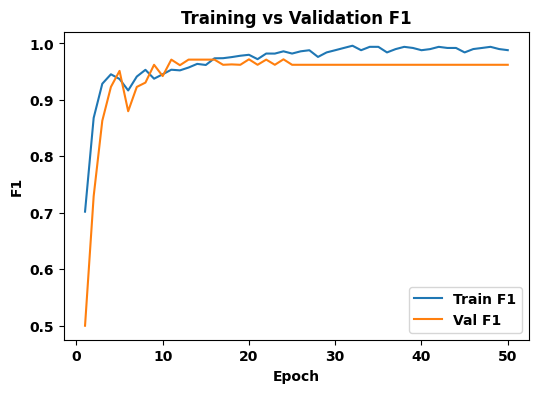

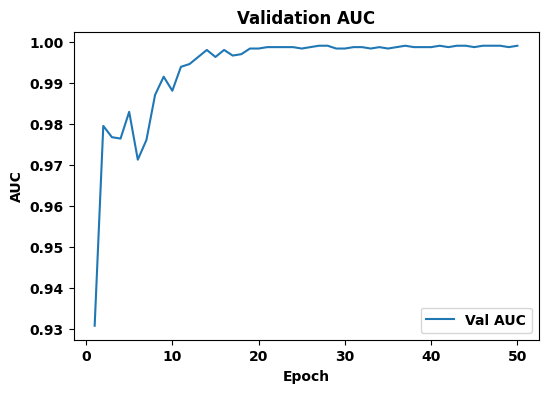

In [25]:
# Set global bold style for most text elements
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['legend.handlelength'] = 2

def bold_tick_labels():
    """Make tick labels bold for the current figure"""
    ax = plt.gca()
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight('bold')

epochs_range = range(1, len(train_losses) + 1)

# Figure 1: Loss
plt.figure(figsize=(6, 4))
plt.plot(epochs_range, train_losses, label="Train Loss")
plt.plot(epochs_range, val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
bold_tick_labels()
plt.show()

# Figure 2: Accuracy
plt.figure(figsize=(6, 4))
plt.plot(epochs_range, train_accuracies, label="Train Acc")
plt.plot(epochs_range, val_accuracies, label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
bold_tick_labels()
plt.show()

# Figure 3: F1 Score
plt.figure(figsize=(6, 4))
plt.plot(epochs_range, train_f1s, label="Train F1")
plt.plot(epochs_range, val_f1s, label="Val F1")
plt.xlabel("Epoch")
plt.ylabel("F1")
plt.title("Training vs Validation F1")
plt.legend()
bold_tick_labels()
plt.show()

# Figure 4: Validation AUC
plt.figure(figsize=(6, 4))
plt.plot(epochs_range, val_aucs, label="Val AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.title("Validation AUC")
plt.legend()
bold_tick_labels()
plt.show()

## Part 3: Evaluate the Model

In [26]:
#best_model_path = "/content/drive/MyDrive/XST-Deepfake-Detection/new_version/video_best_model.pth"

In [27]:
model.load_state_dict(torch.load(model_path, map_location=device))

C:\Users\fatah.rahimi\AppData\Local\Temp\ipykernel_2772\1340442549.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_locat

<All keys matched successfully>

In [28]:
def test_model(model, loader, device):
    model.eval()

    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for videos, labels in tqdm(loader, desc="Testing"):
            videos = videos.to(device)
            labels = labels.unsqueeze(1).to(device)

            outputs = model(videos)
            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).float()

            all_labels.extend(labels.cpu().numpy().ravel())
            all_preds.extend(preds.cpu().numpy().ravel())
            all_probs.extend(probs.cpu().numpy().ravel())

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    auc = roc_auc_score(all_labels, all_probs)

    print(f"Test Accuracy: {acc:.4f}")
    print(f"Test F1-score: {f1:.4f}")
    print(f"Test AUC: {auc:.4f}")

    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

In [29]:
all_labels, all_preds, all_probs = test_model(model, test_loader, device)

Testing: 100%|██████████| 14/14 [00:22<00:00,  1.59s/it]

Test Accuracy: 0.9550
Test F1-score: 0.9524
Test AUC: 0.9854


              precision    recall  f1-score   support

        fake       0.92      1.00      0.96        56
        real       1.00      0.91      0.95        55

    accuracy                           0.95       111
   macro avg       0.96      0.95      0.95       111
weighted avg       0.96      0.95      0.95       111

Confusion Matrix:
 [[56  0]
 [ 5 50]]


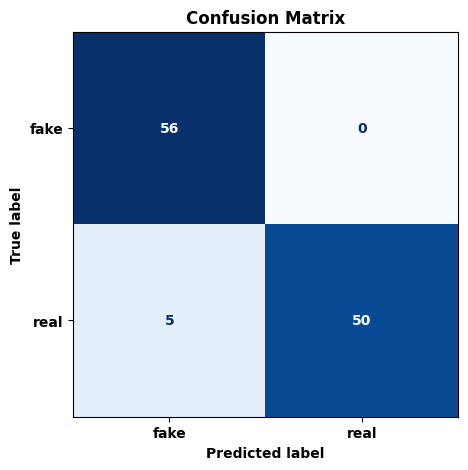

In [30]:
target_names = ["fake", "real"]

print(classification_report(
    all_labels.astype(int),
    all_preds.astype(int),
    target_names=target_names
))

cm = confusion_matrix(all_labels.astype(int), all_preds.astype(int))
print("Confusion Matrix:\n", cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(cmap="Blues", colorbar=False, ax=ax)
plt.title("Confusion Matrix")
plt.show()